# Homework 2
#### EE-556 Mathematics of Data - Fall 2024

This homework covers Lectures 8-12. Please take a look at the material for the context and notation.

In this homework we will study minimax problems. We will begin with some theoretical analysis and in a second part you will implement a Wasserstein Generative Adversarial Network (WGAN). 

These notebooks should expose you to the fundamentals of GAN training at a basic level, as well as some of the theory behind it.

## 1. Minimax problems - 65 points

### 1.1 Theoretical recap: stationary points and convergence in minmax games - 25 points

Consider a stylized function $f:\mathbb{R}^4 \to \mathbb{R}$ with variables $x_1,x_2,y_1,y_2$, we denote by
$x=(x_1,x_2) \in \mathbb{R}^2$, $y=(y_1,y_2) \in \mathbb{R}^2$, the function has the form of
$
f(x,y) = (a x - b)^\top (a y - c), \quad a \neq 0, \; b,c \in \mathbb{R}^2.
$


__(1)__ (5 points) Write down the first-order stationary points of $f$, and
        classify them as local minimum, local maximum, or saddle point by
        inspecting its Hessian.




$$f(x,y) = (ax - b)^\top (ay - c) = a^2 x^\top y - a c^\top x - a b^\top y + b^\top c$$
Gradient with respect to $x$:
$$\nabla_x f = a^2 y - a c = a(ay - c)$$
Gradient with respect to $y$:
$$\nabla_y f = a^2 x - a b = a(ax - b)$$

Stationary points satisfy:
$$\begin{cases}
\nabla_x f = 0 \\
\nabla_y f = 0
\end{cases} \Rightarrow \begin{cases}
a(ay - c) = 0 \\
a(ax - b) = 0
\end{cases}$$
Since $a \neq 0$, we have:
$$\begin{cases}
ay - c = 0 \Rightarrow y = \frac{c}{a} \\
ax - b = 0 \Rightarrow x = \frac{b}{a}
\end{cases}$$
The unique stationary point is:
$$(x, y) = \left(\frac{b}{a}, \frac{c}{a}\right)$$

The Hessian matrix is:
$$H = \begin{bmatrix}
\frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} \\
\frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2}
\end{bmatrix}$$
Computing the second-order partial derivatives:
$\frac{\partial^2 f}{\partial x^2} = 0_{2×2}$ (zero matrix)
$\frac{\partial^2 f}{\partial y^2} = 0_{2×2}$ (zero matrix)
$\frac{\partial^2 f}{\partial x \partial y} = a^2 I_2$ (identity matrix)
$\frac{\partial^2 f}{\partial y \partial x} = a^2 I_2$
Therefore, the full Hessian matrix (4×4) is:
$$H = \begin{bmatrix}
0_{2×2} & a^2 I_2 \\
a^2 I_2 & 0_{2×2}
\end{bmatrix} = \begin{bmatrix}
0 & 0 & a^2 & 0 \\
0 & 0 & 0 & a^2 \\
a^2 & 0 & 0 & 0 \\
0 & a^2 & 0 & 0
\end{bmatrix}$$

To classify the stationary point, we examine the eigenvalues of $H$.
For the block matrix structure:
$$H = \begin{bmatrix}
0 & a^2 I \\
a^2 I & 0
\end{bmatrix}$$
The eigenvalues are: $\lambda = \pm a^2$ (each with multiplicity 2).
Since the Hessian has both positive eigenvalues ($+a^2$) and negative eigenvalues ($-a^2$), the stationary point is a saddle point.

__(2)__ (5 points) Find the solution $(x^\star,y^\star)$ to the
        minimax problem $\min_x \max_y f(x, y)$. You can quantify the solution
        by using the following saddle point inequality:  $f(x^\star, y^\star)
        \geq f(x^\star, y)$ and $f(x^\star, y^\star) \leq f(x, y^\star)$, for
        all $x, y$.
        
**HINT:** $(x^\star, y^\star)$ can only be one of the critical points you found in (1), just evaluate $f$ at every place in the inequalities to check the optimality!




From Problem (1), we found that the unique stationary point is:
$$(x^*, y^*) = \left(\frac{b}{a}, \frac{c}{a}\right)$$
The function is:
$$f(x,y) = (ax - b)^\top (ay - c) = a^2 x^\top y - a c^\top x - a b^\top y + b^\top c$$

At $$(x^*, y^*) = \left(\frac{b}{a}, \frac{c}{a}\right)$$:
$$f(x^*, y^*) = f\left(\frac{b}{a}, \frac{c}{a}\right) = a^2 \left(\frac{b}{a}\right)^\top \left(\frac{c}{a}\right) - a c^\top \left(\frac{b}{a}\right) - a b^\top \left(\frac{c}{a}\right) + b^\top c$$
$$= a^2 \cdot \frac{b^\top c}{a^2} - b^\top c - b^\top c + b^\top c = b^\top c - b^\top c = 0$$
So $f(x^*, y^*) = 0$.

we need to show, $f(x^*, y^*) \geq f(x^*, y)$ for all $y$.
That is: $f(b/a, y) \leq 0$ for all $y$.
Compute $f(b/a, y)$:
$$f\left(\frac{b}{a}, y\right) = a^2 \left(\frac{b}{a}\right)^\top y - a c^\top \left(\frac{b}{a}\right) - a b^\top y + b^\top c$$
$$= a b^\top y - b^\top c - a b^\top y + b^\top c = 0$$
Therefore, $f(b/a, y) = 0$ for all $y$, which means:
$$f(x^*, y^*) = 0 = f(x^*, y) \quad \text{for all } y$$
So the first inequality holds (with equality): $f(x^*, y^*) \geq f(x^*, y)$ 


We need to show: $f(x^*, y^*) \leq f(x, y^*)$ for all $x$.
That is: $f(x, c/a) \geq 0$ for all $x$.
Compute $f(x, c/a)$:
$$f\left(x, \frac{c}{a}\right) = a^2 x^\top \left(\frac{c}{a}\right) - a c^\top x - a b^\top \left(\frac{c}{a}\right) + b^\top c$$
$$= a c^\top x - a c^\top x - b^\top c + b^\top c = 0$$
Therefore, $f(x, c/a) = 0$ for all $x$, which means:
$$f(x^, y^) = 0 = f(x, y^) \quad \text{for all } x$$
So the second inequality holds (with equality): $f(x^*, y^*) \leq f(x, y^*)$ 

Since both saddle point inequalities are satisfied (with equality), the point $(x^*, y^*) = (\frac{b}{a}, \frac{c}{a})$ is indeed the solution to the minimax problem:
$$\min_x \max_y f(x, y) = f\left(\frac{b}{a}, \frac{c}{a}\right) = 0$$

__(3)__ (15 points) One possible attempt at finding this solution via iterative
        first-order methods is to perform gradient updates on the variables $x$
        and $y$. More precisely for $\gamma > 0$ consider the simultaneous gradient
        descent/ascent updates
        
\begin{equation}
    x^{k+1} = x^k - \gamma \nabla_x f(x^k, y^k), \qquad
    y^{k+1} = y^k + \gamma \nabla_y f(x^k, y^k) \nonumber
\end{equation}
Show that the sequence of iterates $\{x^k, y^k \}_{k=0}^\infty$ starting
from any point $(x^0, y^0) \neq (x^\star, y^\star)$ diverges, for any $\gamma > 0$.
Find the rate at which the distance from 
$(x^\star,y^\star)$ to the sequence $\{x^k, y^k \}$ grows as the number of iterations $k$ increases.

**HINT:** Define $d_k^2=||(x^k,y^k)-(x^\star, y^\star)||_2^2$ as the sequence of squared distances to the optimum. If you find a formula for how $d_{k+1}$ depends on $d_k$ using the exact gradient updates for our $f$, you can easily argue for the divergence and the rate.

For the function $f(x,y) = (ax - b)^\top (ay - c)$, we have:
\begin{align*}
\nabla_x f &= a^2 y - a c = a(ay - c) \\
\nabla_y f &= a^2 x - a b = a(ax - b)
\end{align*}

The optimal solution is $(x^*, y^*) = (b/a, c/a)$. Define error vectors:
\begin{align*}
u^k &= x^k - x^* = x^k - \frac{b}{a} \\
v^k &= y^k - y^* = y^k - \frac{c}{a}
\end{align*}

The squared distance to the optimum is:
$$d_k^2 = \|(x^k, y^k) - (x^*, y^*)\|_2^2 = \|u^k\|^2 + \|v^k\|^2$$

The simultaneous gradient descent/ascent updates are:
\begin{align*}
x^{k+1} &= x^k - \gamma \nabla_x f(x^k, y^k) = x^k - \gamma a(ay^k - c) \\
y^{k+1} &= y^k + \gamma \nabla_y f(x^k, y^k) = y^k + \gamma a(ax^k - b)
\end{align*}

Noting that:
\begin{align*}
ay^k - c &= a(y^k - c/a) = a \cdot v^k \\
ax^k - b &= a(x^k - b/a) = a \cdot u^k
\end{align*}

The updates become:
\begin{align*}
x^{k+1} &= x^k - \gamma a^2 v^k \\
y^{k+1} &= y^k + \gamma a^2 u^k
\end{align*}

Transforming to error vectors:
\begin{align*}
u^{k+1} &= x^{k+1} - x^* = (x^k - \gamma a^2 v^k) - x^* = u^k - \gamma a^2 v^k \\
v^{k+1} &= y^{k+1} - y^* = (y^k + \gamma a^2 u^k) - y^* = v^k + \gamma a^2 u^k
\end{align*}

The update equations can be written in matrix form:
$$\begin{bmatrix} u^{k+1} \\ v^{k+1} \end{bmatrix} = \begin{bmatrix} 1 & -\gamma a^2 \\ \gamma a^2 & 1 \end{bmatrix} \begin{bmatrix} u^k \\ v^k \end{bmatrix}$$

Define the matrix:
$$A = \begin{bmatrix} 1 & -\gamma a^2 \\ \gamma a^2 & 1 \end{bmatrix}$$

Then:
$$\begin{bmatrix} u^{k+1} \\ v^{k+1} \end{bmatrix} = A \begin{bmatrix} u^k \\ v^k \end{bmatrix}$$

The squared distance is:
$$d_k^2 = \|u^k\|^2 + \|v^k\|^2$$


Computing $d_{k+1}^2$:
\begin{align*}
d_{k+1}^2 &= \|u^{k+1}\|^2 + \|v^{k+1}\|^2 \\
&= \|u^k - \gamma a^2 v^k\|^2 + \|v^k + \gamma a^2 u^k\|^2
\end{align*}

Expanding the first term:
\begin{align*}
\|u^k - \gamma a^2 v^k\|^2 &= (u^k - \gamma a^2 v^k)^\top (u^k - \gamma a^2 v^k) \\
&= \|u^k\|^2 - 2\gamma a^2 (u^k)^\top v^k + \gamma^2 a^4 \|v^k\|^2
\end{align*}

Expanding the second term:
\begin{align*}
\|v^k + \gamma a^2 u^k\|^2 &= (v^k + \gamma a^2 u^k)^\top (v^k + \gamma a^2 u^k) \\
&= \|v^k\|^2 + 2\gamma a^2 (v^k)^\top u^k + \gamma^2 a^4 \|u^k\|^2
\end{align*}

Combining:
\begin{align*}
d_{k+1}^2 &= \|u^k\|^2 - 2\gamma a^2 (u^k)^\top v^k + \gamma^2 a^4 \|v^k\|^2 \\
&\quad + \|v^k\|^2 + 2\gamma a^2 (v^k)^\top u^k + \gamma^2 a^4 \|u^k\|^2
\end{align*}

Since $(u^k)^\top v^k = (v^k)^\top u^k$, the cross terms cancel:
\begin{align*}
d_{k+1}^2 &= \|u^k\|^2 + \|v^k\|^2 + \gamma^2 a^4 (\|u^k\|^2 + \|v^k\|^2) \\
&= d_k^2 + \gamma^2 a^4 \cdot d_k^2 \\
&= d_k^2(1 + \gamma^2 a^4)
\end{align*}

Since $\gamma > 0$ and $a \neq 0$, we have:
$$1 + \gamma^2 a^4 > 1$$

Therefore:
$$d_{k+1}^2 = d_k^2(1 + \gamma^2 a^4) > d_k^2$$

This means the squared distance is monotonically increasing, so the sequence diverges.

From the recurrence relation:
$$d_{k+1}^2 = d_k^2(1 + \gamma^2 a^4)$$

$$d_k^2 = d_0^2(1 + \gamma^2 a^4)^k$$

$$d_k = d_0 (1 + \gamma^2 a^4)^{k/2}$$

Since $1 + \gamma^2 a^4 > 1$, the term $(1 + \gamma^2 a^4)^{k/2}$ grows exponentially with $k$.

The divergence rate is exponential with growth factor $(1 + \gamma^2 a^4)^{1/2}$.


__(Optional $\star$)__ A second attempt at finding the solution via _alternating_ gradient descent ascent on $x$
        and $y$. More precisely for $\gamma > 0$ consider the update
        
\begin{equation}
    x^{k+1} = x^k - \gamma \nabla_x f(x^k, y^k), \qquad
    y^{k+1} = y^k + \gamma \nabla_y f(x^{k+1}, y^k) \nonumber
\end{equation}
Show that the sequence of iterates $\{x^k, y^k \}_{k=0}^\infty$ starting
from any point $(x^0, y^0) \neq (x^\star, y^\star)$ i) never converges, ii) but still remains bounded under certain stepsize conditions.


Note: in this example, for simplicity just consider $f:\mathbb{R}^2 \to \mathbb{R}$ with variables $x,y$, where
$x, y \in \mathbb{R}$, the function has the form of
$
f(x,y) = (a x - b) (a y - c), \quad a \neq 0, \; b,c \in \mathbb{R}.
$


**HINT**: Reduce the problem to studying a linear system.


For $f(x,y) = (ax - b)(ay - c)$:
\begin{align*}
\nabla_x f &= a(ay - c) = a^2 y - ac \\
\nabla_y f &= a(ax - b) = a^2 x - ab
\end{align*}

The optimal solution is $(x^*, y^*) = (b/a, c/a)$.

The alternating updates are:
\begin{align*}
x^{k+1} &= x^k - \gamma a(ay^k - c) = x^k - \gamma a^2 y^k + \gamma ac \\
y^{k+1} &= y^k + \gamma a(ax^{k+1} - b) = y^k + \gamma a^2 x^{k+1} - \gamma ab
\end{align*}

Define error vectors:
\begin{align*}
u^k &= x^k - x^* = x^k - \frac{b}{a} \\
v^k &= y^k - y^* = y^k - \frac{c}{a}
\end{align*}

For $x^{k+1}$:
\begin{align*}
u^{k+1} &= x^{k+1} - \frac{b}{a} \\
&= (x^k - \gamma a^2 y^k + \gamma ac) - \frac{b}{a} \\
&= (x^k - \frac{b}{a}) - \gamma a^2 (y^k - \frac{c}{a}) - \gamma a^2 \cdot \frac{c}{a} + \gamma ac \\
&= u^k - \gamma a^2 v^k - \gamma ac + \gamma ac \\
&= u^k - \gamma a^2 v^k
\end{align*}

For $y^{k+1}$, substituting $x^{k+1} = u^{k+1} + b/a$:
\begin{align*}
v^{k+1} &= y^{k+1} - \frac{c}{a} \\
&= (y^k + \gamma a^2 x^{k+1} - \gamma ab) - \frac{c}{a} \\
&= (y^k - \frac{c}{a}) + \gamma a^2 (x^{k+1} - \frac{b}{a}) + \gamma a^2 \cdot \frac{b}{a} - \gamma ab \\
&= v^k + \gamma a^2 u^{k+1} + \gamma ab - \gamma ab \\
&= v^k + \gamma a^2 u^{k+1}
\end{align*}

Substituting $u^{k+1} = u^k - \gamma a^2 v^k$ into the second equation:
\begin{align*}
v^{k+1} &= v^k + \gamma a^2 (u^k - \gamma a^2 v^k) \\
&= v^k + \gamma a^2 u^k - \gamma^2 a^4 v^k \\
&= (1 - \gamma^2 a^4) v^k + \gamma a^2 u^k
\end{align*}

The update equations in matrix form:
$$\begin{bmatrix} u^{k+1} \\ v^{k+1} \end{bmatrix} = \begin{bmatrix} 1 & -\gamma a^2 \\ \gamma a^2 & 1 - \gamma^2 a^4 \end{bmatrix} \begin{bmatrix} u^k \\ v^k \end{bmatrix}$$

Define the matrix:
$$A = \begin{bmatrix} 1 & -\gamma a^2 \\ \gamma a^2 & 1 - \gamma^2 a^4 \end{bmatrix}$$

Then:
$$\begin{bmatrix} u^{k+1} \\ v^{k+1} \end{bmatrix} = A \begin{bmatrix} u^k \\ v^k \end{bmatrix}$$

To find eigenvalues $\lambda$ of $A$, solve $\det(A - \lambda I) = 0$:
$$\det\begin{bmatrix} 1 - \lambda & -\gamma a^2 \\ \gamma a^2 & 1 - \gamma^2 a^4 - \lambda \end{bmatrix} = 0$$

Computing the determinant:
\begin{align*}
(1 - \lambda)(1 - \gamma^2 a^4 - \lambda) + \gamma^2 a^4 &= 0 \\
(1 - \lambda)(1 - \gamma^2 a^4 - \lambda) &= -\gamma^2 a^4 \\
(1 - \lambda)(1 - \gamma^2 a^4 - \lambda) + \gamma^2 a^4 &= 0
\end{align*}

Expanding:
\begin{align*}
(1 - \lambda)(1 - \gamma^2 a^4 - \lambda) + \gamma^2 a^4 &= 0 \\
1 - \gamma^2 a^4 - \lambda - \lambda + \gamma^2 a^4 \lambda + \lambda^2 + \gamma^2 a^4 &= 0 \\
1 - 2\lambda + \gamma^2 a^4 \lambda + \lambda^2 &= 0 \\
\lambda^2 - 2\lambda + 1 + \gamma^2 a^4 \lambda &= 0 \\
\lambda^2 + (\gamma^2 a^4 - 2)\lambda + 1 &= 0
\end{align*}

Using the quadratic formula:
$$\lambda = \frac{2 - \gamma^2 a^4 \pm \sqrt{(\gamma^2 a^4 - 2)^2 - 4}}{2}$$

Simplifying:
\begin{align*}
\lambda &= \frac{2 - \gamma^2 a^4 \pm \sqrt{\gamma^4 a^8 - 4\gamma^2 a^4 + 4 - 4}}{2} \\
&= \frac{2 - \gamma^2 a^4 \pm \sqrt{\gamma^4 a^8 - 4\gamma^2 a^4}}{2} \\
&= \frac{2 - \gamma^2 a^4 \pm \gamma a^2 \sqrt{\gamma^2 a^4 - 4}}{2}
\end{align*}

The behavior depends on the discriminant $\Delta = \gamma^4 a^8 - 4\gamma^2 a^4 = \gamma^2 a^4 (\gamma^2 a^4 - 4)$.

Case 1: $\gamma^2 a^4 < 4$ (i.e., $\gamma < 2/|a|^2$)

In this case, $\Delta < 0$, so the eigenvalues are complex:
$$\lambda = \frac{2 - \gamma^2 a^4 \pm i \gamma a^2 \sqrt{4 - \gamma^2 a^4}}{2}$$

The magnitude is:
\begin{align*}
|\lambda|^2 &= \left(\frac{2 - \gamma^2 a^4}{2}\right)^2 + \left(\frac{\gamma a^2 \sqrt{4 - \gamma^2 a^4}}{2}\right)^2 \\
&= \frac{(2 - \gamma^2 a^4)^2}{4} + \frac{\gamma^2 a^4 (4 - \gamma^2 a^4)}{4} \\
&= \frac{4 - 4\gamma^2 a^4 + \gamma^4 a^8 + 4\gamma^2 a^4 - \gamma^4 a^8}{4} \\
&= \frac{4}{4} = 1
\end{align*}

Therefore, $|\lambda| = 1$ for both eigenvalues.

Case 2: $\gamma^2 a^4 = 4$

In this case, $\Delta = 0$, and $\lambda = 1 - \gamma^2 a^4/2 = 1 - 2 = -1$, so $|\lambda| = 1$.

Case 3: $\gamma^2 a^4 > 4$

In this case, both eigenvalues are real. For stability, we need to check if $|\lambda| < 1$. This requires careful analysis of the step size.

For $\gamma^2 a^4 \leq 4$, we have $|\lambda| = 1$ for all eigenvalues.

If the sequence converged to $(x^*, y^*)$, then $(u^k, v^k) \to (0, 0)$. But since the iteration is:
$$\begin{bmatrix} u^k \\ v^k \end{bmatrix} = A^k \begin{bmatrix} u^0 \\ v^0 \end{bmatrix}$$

and $|\lambda| = 1$ implies that $A^k$ does not converge to the zero matrix, we have a contradiction unless $(u^0, v^0) = (0, 0)$, which contradicts the assumption $(x^0, y^0) \neq (x^*, y^*)$.

For $\gamma^2 a^4 > 4$, the eigenvalues are real. Even if one eigenvalue has $|\lambda| > 1$ (which would cause divergence), the sequence still does not converge to $(x^*, y^*)$ because convergence would require $(u^k, v^k) \to (0, 0)$, which is impossible when $|\lambda| \geq 1$ for all eigenvalues.

Therefore, the sequence never converges for any $\gamma > 0$.

For boundedness, we need all eigenvalues to satisfy $|\lambda| \leq 1$.

Case 1: $\gamma^2 a^4 \leq 4$

In this case, we have $|\lambda| = 1$ for all eigenvalues (as shown in Step 7). Since $|\lambda| = 1$, we have $|\lambda^k| = 1$ for all $k$. If $A$ can be diagonalized as $A = P \Lambda P^{-1}$ where $\Lambda$ contains the eigenvalues, then:
$$A^k = P \Lambda^k P^{-1}$$

Since $|\lambda^k| = 1$ for all eigenvalues, the matrix $A^k$ remains bounded. Therefore:
$$\left\|\begin{bmatrix} u^k \\ v^k \end{bmatrix}\right\| = \left\|A^k \begin{bmatrix} u^0 \\ v^0 \end{bmatrix}\right\| \leq \|A^k\| \cdot \left\|\begin{bmatrix} u^0 \\ v^0 \end{bmatrix}\right\| < \infty$$

This shows that the sequence remains bounded.

Case 2: $\gamma^2 a^4 > 4$

In this case, the eigenvalues are real:
$$\lambda_1 = \frac{2 - \gamma^2 a^4 + \gamma a^2 \sqrt{\gamma^2 a^4 - 4}}{2}$$
$$\lambda_2 = \frac{2 - \gamma^2 a^4 - \gamma a^2 \sqrt{\gamma^2 a^4 - 4}}{2}$$

For $\lambda_2$, since $\gamma^2 a^4 > 4$, we have:
\begin{align*}
2 - \gamma^2 a^4 &< 2 - 4 = -2 \\
\gamma a^2 \sqrt{\gamma^2 a^4 - 4} &> 0
\end{align*}

Therefore:
$$\lambda_2 = \frac{2 - \gamma^2 a^4 - \gamma a^2 \sqrt{\gamma^2 a^4 - 4}}{2} < \frac{-2 - 0}{2} = -1$$

So $|\lambda_2| > 1$, which means the sequence diverges (unbounded).

Conclusion:

The sequence remains bounded if and only if $\gamma^2 a^4 \leq 4$, i.e., $\gamma \leq 2/|a|^2$.

Under this stepsize condition, the sequence remains bounded but never converges .



### 1.2 A concrete example: Rock - Paper - Scissors - Lizard - Spock - 40 points

To make your previous abstract analysis more concrete, we will now look at the iconic Rock-Paper-Scissors-Lizard-Spock game. Sheldon and Leonard always like to settle their differences through a round of this game, whose rules they state as follows:

*"Scissors cuts Paper, Paper covers Rock, Rock crushes Lizard, Lizard poisons Spock, Spock smashes Scissors, Scissors decapitates Lizard, Lizard eats Paper, Paper disproves Spock, Spock vaporizes Rock, (and as it always has) Rock crushes Scissors"*

Sheldon and Leonard always pick to play Spock because "logic trumps all", it will be your task to show that this is not the optimal strategy.

We can formalize the game as follows. There are two players, the `x` player (e.g. Sheldon) and the `y` player (e.g. Leonard). There is only one single round. The players play a randomized strategy: each player chooses a probability of playing rock/paper/scissors/lizard/Spock. We look at the expected pay-off of these randomized strategies. 

In other words, the players choose an element in $\Delta_5$ the probability simplex in dimension 5. The `x` player chooses a vector $\mathbf{x} = \begin{bmatrix} \mathbf{x}_1 & \mathbf{x}_2 & \mathbf{x}_3 & \mathbf{x}_4 & \mathbf{x}_5 \end{bmatrix} \in \Delta_5$ where $\mathbf{x}_1$ is the probability of playing `Rock`, $\mathbf{x}_2$ is the probability of playing `Paper`, $\mathbf{x}_3$ is the probability of playing `Scissors`, $\mathbf{x}_4$ is the probability of playing `Lizard`, $\mathbf{x}_5$ is the probability of playing `Spock`. The `y` player chooses a vector $\mathbf{y} \in \Delta_5$ defined in the same way. 

The game designers decide that winning the game gives 1 point and a tie gives 0 points. So the expected payoff for a give choice of strategies $\mathbf{x}, \mathbf{y}$ is obtained by computing:
$$
\mathbf{x}^\top \begin{bmatrix} 0 & 1 & -1 & -1 & 1 \\ -1 & 0 & 1 & 1 & -1 \\ 1 & -1 & 0 & -1 & 1 \\ 1 & -1 & 1 & 0 & -1 \\ -1 & 1 & -1 & 1 & 0 \end{bmatrix}\mathbf{y}
$$

The `x` player wants to minimize this expected payoff and the `y` player wants to maximize it. So the problem we seek to solve is

$$
\min_{\mathbf{x} \in \Delta_5} \max_{\mathbf{y} \in \Delta_5} \mathbf{x}^\top \mathbf{M}\mathbf{y} =: f(\mathbf{x}, \mathbf{y})
$$
with $\mathbf{M} = \begin{bmatrix} 0 & 1 & -1 & -1 & 1 \\ -1 & 0 & 1 & 1 & -1 \\ 1 & -1 & 0 & -1 & 1 \\ 1 & -1 & 1 & 0 & -1 \\ -1 & 1 & -1 & 1 & 0 \end{bmatrix}$.

In the following cells, you will implement methods to solve this game and find the optimal strategies.

In [1]:
import torch
from ipywidgets import interact, SelectionSlider, fixed
from itertools import combinations
from scipy.stats import entropy
from lib.utils import *

**(1)** (2 points) Implement the objective function $f$ given two 3 dimensional vectors `x` and `y` stored as `torch.Tensor` objects.

In [14]:
M = torch.tensor([
    [0, 1, -1, -1, 1],
    [-1, 0, 1, 1, -1],
    [1, -1, 0, -1, 1],
    [1, -1, 1, 0, -1],
    [-1, 1, -1, 1, 0]
], dtype=torch.float32)
def f(x: torch.Tensor, y: torch.Tensor):
    return x.T @ (M @ y)

In [15]:
# test
x = torch.tensor([0.2, 0.2, 0.2, 0.2, 0.2])
y = torch.tensor([0.2, 0.2, 0.2, 0.2, 0.2])

val = f(x, y)

print("M @ y =", M @ y)
print("x @ (M @ y) =", val.item())

M @ y = tensor([0., 0., 0., 0., 0.])
x @ (M @ y) = 0.0


**(2)** (10 points) Implement a single step of the simultaneous gradient descent/ascent studied in question 1.1.(3). Since we are in a constrained setting, make sure you include a projection step onto the simplex. 

The function `GDA` you will implement takes in the objective function `f`, the two current strategies of the players stored in tensors `x` and `y` and a step_size. Write the function so that it modifies the variables `x` and `y` in place without returning anything.

We provide you with a function called `simplex_project` that projects a vector on the probability simplex. The function has no return value and does the projection in place. Use `Pytorch` to compute gradients automatically. 

__Hints__: Review what a call to `.backward()` on a tensor does. Review what in-place operations are like `.add_`. Think of which steps need to be in a `with torch.no_grad()` block. Remember to zero the gradients before re-using them.

In [41]:
def GDA(f, x, y, step_size):
    if x.grad is not None:
        x.grad.zero_()
    if y.grad is not None:
        y.grad.zero_()
    
    payoff = f(x, y)

    payoff.backward()

    with torch.no_grad():
        x.sub_(step_size * x.grad)
        y.add_(step_size * y.grad)

        simplex_project(x)
        simplex_project(y)


We can run this algorithm initialized from Sheldon and Leonard's strategies of always playing Spock.

In [42]:
x_init = torch.tensor([0.0, 0.0, 0.0, 0.0, 1.0])
y_init = torch.tensor([0.0, 0.0, 0.0, 0.0, 1.0])

gda_x_sequence, gda_y_sequence = run_alg(GDA, f, x_init, y_init, step_size=0.05, n_iterations=2500)

We can visualize this sequence as ${4 \choose 2} = 6$ two dimensional slices since the simplex $\Delta_5$ is 4-dimensional.

In [43]:
dim_pairs = list(combinations(range(4), 2))
def visualize_seq_slice(dim_pair):
    visualize_seq(gda_x_sequence[:, dim_pairs[dim_pair]], 
                  gda_y_sequence[:, dim_pairs[dim_pair]],
                  dim_pairs[dim_pair])
interact(visualize_seq_slice, dim_pair=SelectionSlider(
    options=range(len(dim_pairs)),
    value=0,
    description="Dim pair:",
    disabled=False,
    continuous_update=False,
    orientation="horizontal",
    readout=True
))

interactive(children=(SelectionSlider(continuous_update=False, description='Dim pair:', options=(0, 1, 2, 3, 4…

<function __main__.visualize_seq_slice(dim_pair)>

To have plots that aggregate the convergence status over all 5 dimensions at the same time, let's also visualize:

- the duality gap over time: $g_k = \max_{\mathbf{y} \in \Delta_5}{f(\mathbf{x}_k,\mathbf{y})} - \min_{\mathbf{x} \in \Delta_5}{f(\mathbf{x},\mathbf{y}_k)} = \max_{i}{(\mathbf{M}^\top \mathbf{x}_k)_i} - \min_{i}{(\mathbf{M} \mathbf{y}_k)_i}$
- the distance to the optimum over time: $d_k=\sqrt{||\mathbf{x}_k-\mathbf{x}^\star||_2^2 + ||\mathbf{y}_k-\mathbf{y}^\star||_2^2}$
- the discrete entropy over time of the x and y strategies (we can do this since they are probability distributions): $H(\mathbf{x}_k)=-\sum_{i=1}^{5}{\mathbf{x}_k^{(i)}\log{\mathbf{x}_k^{(i)}}}, H(\mathbf{y}_k)=-\sum_{i=1}^{5}{\mathbf{y}_k^{(i)}\log{\mathbf{y}_k^{(i)}}}$

In [44]:
def distance_to_opt(L_x, L_y):
    return np.sqrt(np.sum((L_x - 0.2) ** 2 + (L_y - 0.2) ** 2, axis=1))

In [45]:
def duality_gap(L_x, L_y):
    return (np.max(M.numpy().T.reshape(1, 5, 5) @ L_x.reshape(-1, 5, 1), axis=(1, 2)) 
            - np.min(M.numpy().reshape(1, 5, 5) @ L_y.reshape(-1, 5, 1), axis=(1, 2)))

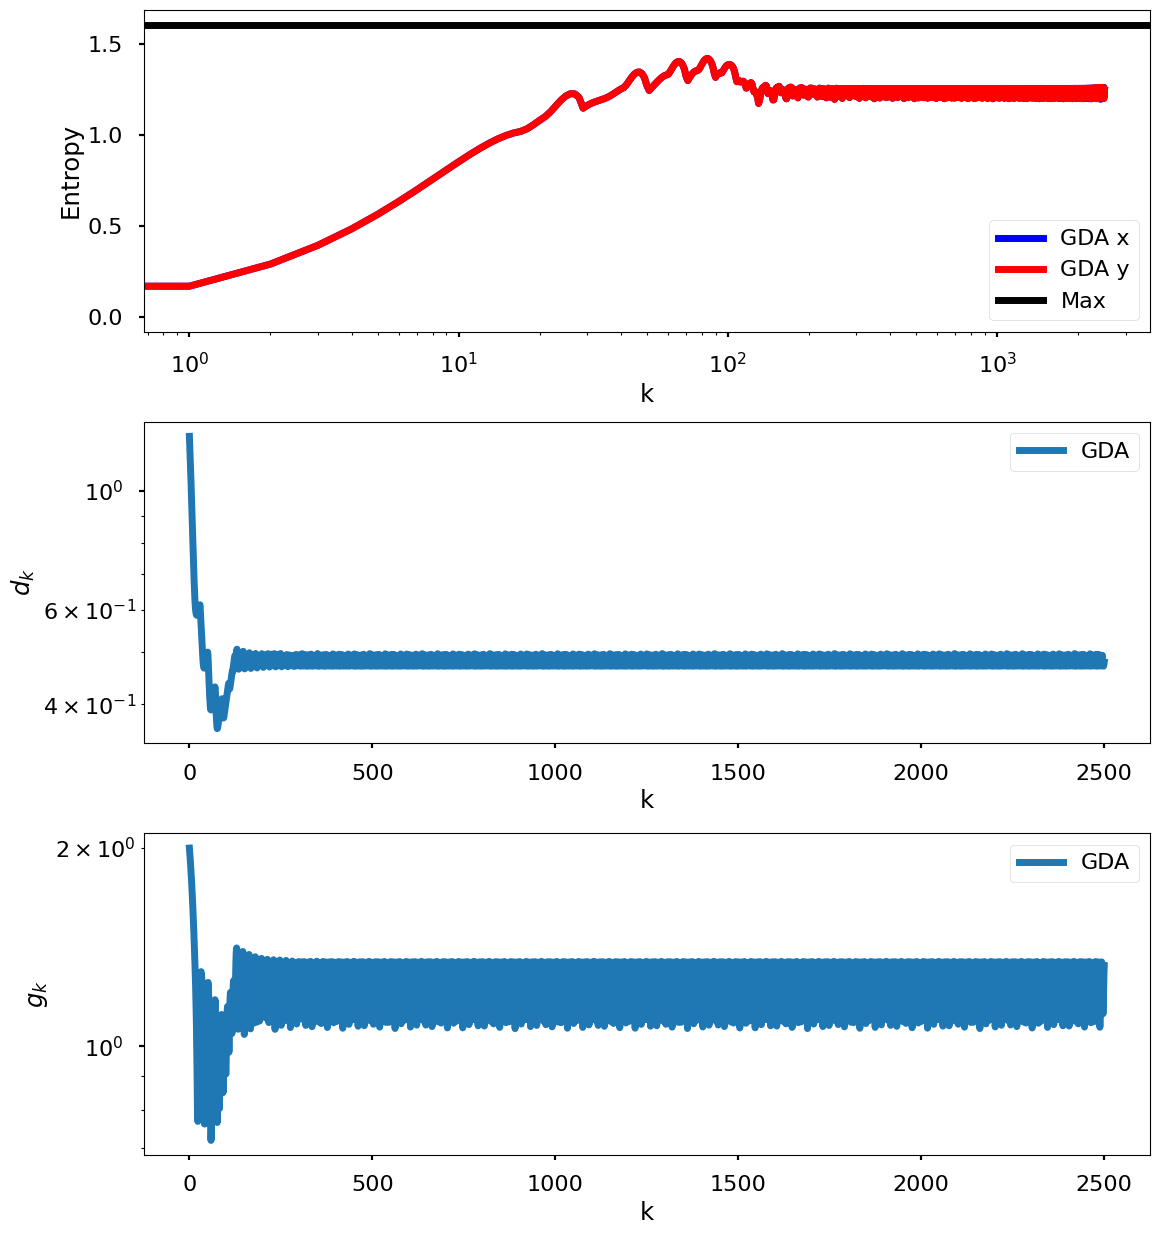

In [46]:
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(3, 1, figsize=(11.7, 1.5 * 8.3))
ax[0].plot(range(len(gda_x_sequence)), entropy(gda_x_sequence, axis=1), lw=5, color='b', label="GDA x")
ax[0].plot(range(len(gda_y_sequence)), entropy(gda_y_sequence, axis=1), lw=5, color='r', label="GDA y")
ax[0].axline((0, np.log(5)), slope=0, color='black', lw=5, label="Max")
ax[0].legend()
ax[0].set_xscale("log")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Entropy")
ax[1].plot(range(len(gda_x_sequence)), distance_to_opt(gda_x_sequence, gda_y_sequence), lw=5, label="GDA")
ax[1].legend()
ax[1].set_yscale("log")
ax[1].set_xlabel("k")
ax[1].set_ylabel("$d_k$")
ax[2].plot(range(len(gda_x_sequence)), duality_gap(gda_x_sequence, gda_y_sequence), lw=5, label="GDA")
ax[2].legend()
ax[2].set_yscale("log")
ax[2].set_xlabel("k")
ax[2].set_ylabel("$g_k$")
fig.tight_layout()
plt.show()

**(3)** (3 point) What kind of behavior do you observe ? Do the iterates converge ? Play with the step_size and the number of iterations.




- GDA fails to converge and instead produces cycles around the equilibrium.

**(4)** (4 points) As you've shown both theoretically and in practice, simultaneous Gradient Descent Ascent (sGDA) cannot solve the problem. You will now implement algorithm that can solve bilinear games. We will denote the projection onto the decision space of the x-player and y-player, $\Pi_{\mathcal X}$ and $\Pi_{\mathcal Y}$, respectively.


Let $\mathbf{z}_k = \begin{bmatrix} x_k \\ y_k \end{bmatrix}$, $\Pi(\mathbf{z})=\begin{bmatrix} \Pi_{\mathcal X}(x) \\ \Pi_{\mathcal Y}(y) \end{bmatrix}$ and $G(\mathbf{z}_k) = \begin{bmatrix} \nabla_x f(x_k,y_k) \\ -\nabla_y f(x_k,y_k) \end{bmatrix}$.

Consider the following implicit updates, which is the `Proximal Point Method ` (PPM) for solving the bilinear games:
\begin{equation}
    \mathbf{z}_{k+1} = \Pi(\mathbf{z}_k - \gamma G(\color{red}{\mathbf{z}_{k+1}})) \nonumber
\end{equation}


Let’s first prove that the Proximal Point Method (PPM) converges in a simple case to build intuition. Consider the aforementioned stylized function $f: \mathbb{R}^2 \to \mathbb{R}$, such that $f(x, y)=xy$, and consider simplified unconstrained probelm, i.e., the projection is the identity map. Prove that PPM converges.

[Hint] Rewrite the implicit update as an explicit update in the form of $z_{k+1} = A z_{k}$ for some matrix $A$.

[Hint] A square matrix $A$ satisfies $\lim_{k \to \infty} A^k = 0$ if its spectral radius $\rho(A) < 1$, where the spectral radius is defined by
$
\rho(A) := \max_i |\lambda_i|,
$
with $\{\lambda_i\}$ denoting the  eigenvalues of $A$.


We consider the bilinear function  $f(x,y)=xy$. 

$$
z_k = 
\begin{pmatrix}
x_k \\[4pt] y_k
\end{pmatrix},
\qquad
G(z)=
\begin{pmatrix}
\nabla_x f \\[4pt] -\nabla_y f
\end{pmatrix}
=
\begin{pmatrix}
y \\[4pt] -x
\end{pmatrix}.
$$

The projection $\Pi$ is the identity, 

$$
z_{k+1} = z_k - \gamma G(z_{k+1}).
$$


$z_{k+1}=(x_{k+1}, y_{k+1})$,

$$
\begin{pmatrix}
x_{k+1}\\[4pt] y_{k+1}
\end{pmatrix}
=
\begin{pmatrix}
x_k\\[4pt] y_k
\end{pmatrix}
-
\gamma
\begin{pmatrix}
y_{k+1}\\[4pt] -x_{k+1}
\end{pmatrix}.
$$

Thus:

$$
x_{k+1} = x_k - \gamma y_{k+1}, \qquad
y_{k+1} = y_k + \gamma x_{k+1}.
$$


Rearrange:

$$
x_{k+1} + \gamma y_{k+1} = x_k,
$$

$$
-\gamma x_{k+1} + y_{k+1} = y_k.
$$

Matrix form:

$$
\begin{pmatrix}
1 & \gamma\\[4pt]
-\gamma & 1
\end{pmatrix}
\begin{pmatrix}
x_{k+1}\\[4pt] y_{k+1}
\end{pmatrix}
=
\begin{pmatrix}
x_k\\[4pt] y_k
\end{pmatrix}.
$$

Therefore:

$$
z_{k+1} = A z_k,
\quad
A = 
\begin{pmatrix}
1 & \gamma\\[4pt]
-\gamma & 1
\end{pmatrix}^{-1}.
$$


Since

$$
\det
\begin{pmatrix}
1 & \gamma\\[4pt]
-\gamma & 1
\end{pmatrix}
= 1+\gamma^2,
$$

we obtain:

$$
A = \frac{1}{1+\gamma^2}
\begin{pmatrix}
1 & -\gamma\\[4pt]
\gamma & 1
\end{pmatrix}.
$$



Eigenvalues of $A$:

$$
\lambda
= \frac{1}{1+\gamma^2}(1 \pm i\gamma).
$$

Their magnitude:

$$
|\lambda| 
= \frac{\sqrt{1+\gamma^2}}{1+\gamma^2}
= \frac{1}{\sqrt{1+\gamma^2}}
< 1.
$$

Hence:

$$
\rho(A) = \frac{1}{\sqrt{1+\gamma^2}} < 1.
$$


Since $\rho(A)<1$, we have:

$$
A^k \to 0,
$$

and therefore:

$$
z_k = A^k z_0 \to 0.
$$

Thus PPM converges to the saddle point $(x^\star , y^\star) = (0,0)$.



**(5)** (6 points)  In general, computing the next iterate $\mathbf{z}_{k+1}$ in PPM requires you to solve a fixed point problem because we are evaluating the gradient at the unknown next iterate. As this is too costly, we circumvent this difficulty by doing an _extrapolation_ step. The idea behind `ExtraGradient` (EG) is to approximate an implicit update with a more tractable one. Define the half steps:

\begin{equation}
    \mathbf{z}_{k+1/2} = \Pi(\mathbf{z}_k - \gamma G(\mathbf{z}_k)) \nonumber
\end{equation}

These half step extrapolation variables will help us to approximate the implicit iterates. We can then write
\begin{equation}
    \mathbf{z}_{k+1} = \Pi(\mathbf{z}_k - \gamma G(\color{green}{\mathbf{z}_{k+1/2}})) \nonumber
\end{equation}
The recursion above defines the ExtraGradient algorithm.

In [62]:
def ExtraGradient(f, x, y, step_size):
    if x.grad is not None:
        x.grad.zero_()
    if y.grad is not None:
        y.grad.zero_()
    
    payoff = f(x, y)
    payoff.backward()

    with torch.no_grad():
        x_half = x.sub(step_size * x.grad)
        y_half = y.add(step_size * y.grad)
        
        simplex_project(x_half)
        simplex_project(y_half)

    x_half.requires_grad_(True)
    y_half.requires_grad_(True)
    payoff_half = f(x_half, y_half)
    payoff_half.backward()

    with torch.no_grad():
        x.sub_(step_size * x_half.grad)
        y.add_(step_size * y_half.grad)

        simplex_project(x)
        simplex_project(y)

In [63]:
eg_x_sequence, eg_y_sequence = run_alg(ExtraGradient, f, x_init, y_init, step_size=0.1, n_iterations=2500)

In [64]:
dim_pairs = list(combinations(range(4), 2))
def visualize_seq_slice(dim_pair):
    visualize_seq(eg_x_sequence[:, dim_pairs[dim_pair]], 
                  eg_y_sequence[:, dim_pairs[dim_pair]],
                  dim_pairs[dim_pair])
interact(visualize_seq_slice, dim_pair=SelectionSlider(
    options=range(len(dim_pairs)),
    value=0,
    description="Dim pair:",
    disabled=False,
    continuous_update=False,
    orientation="horizontal",
    readout=True
))

interactive(children=(SelectionSlider(continuous_update=False, description='Dim pair:', options=(0, 1, 2, 3, 4…

<function __main__.visualize_seq_slice(dim_pair)>

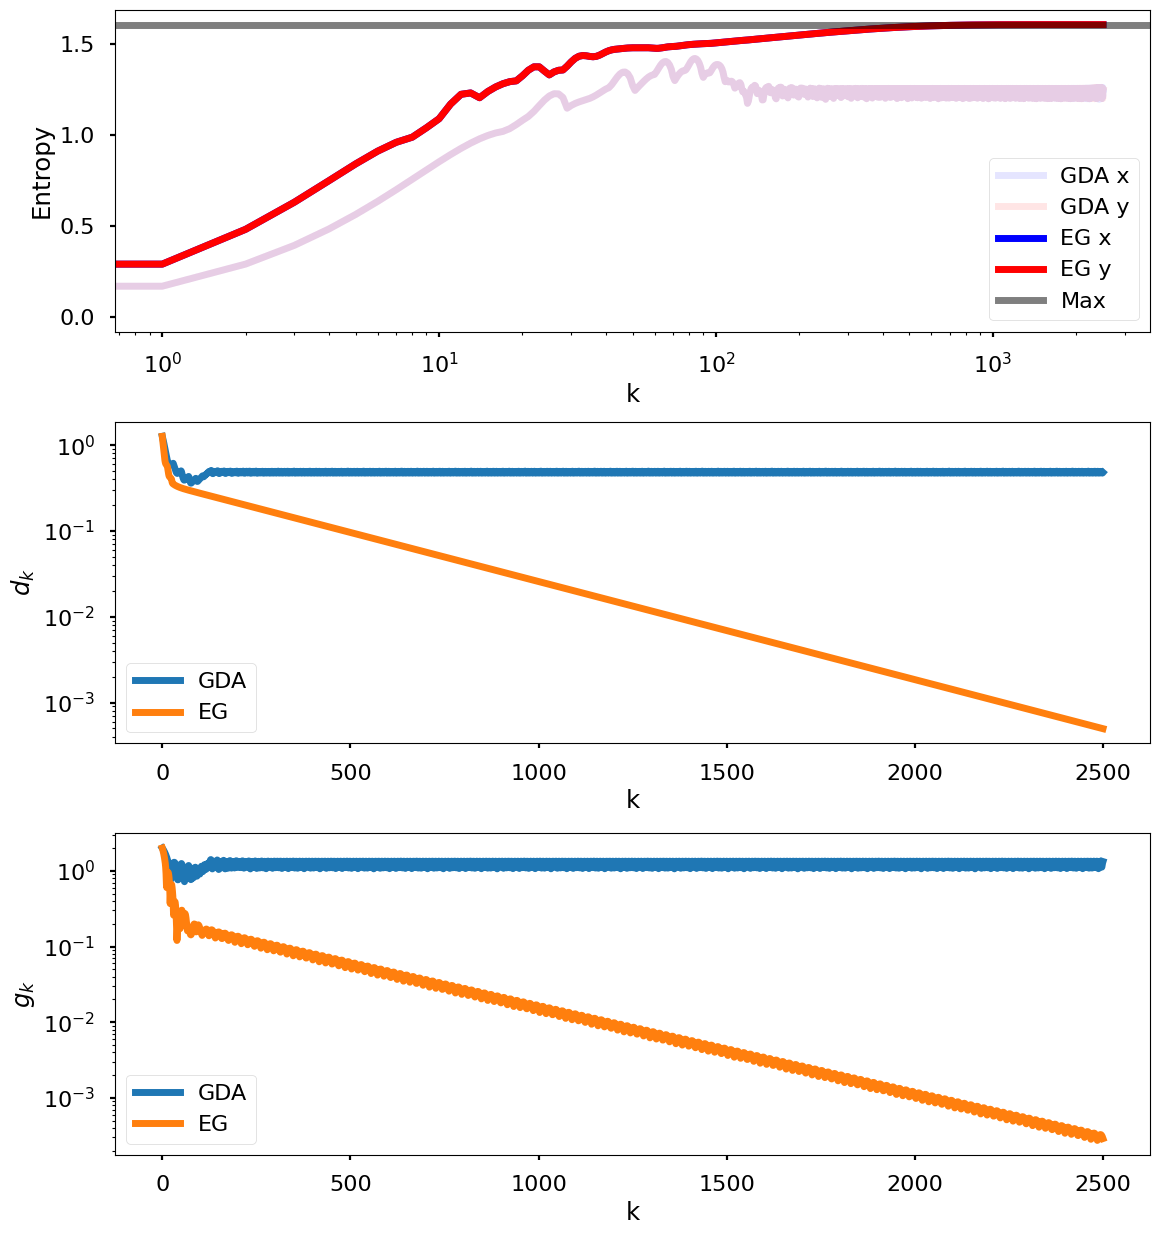

In [65]:
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(3, 1, figsize=(11.7, 1.5 * 8.3))
ax[0].plot(range(len(gda_x_sequence)), entropy(gda_x_sequence, axis=1), lw=5, color='b', alpha=0.1, label="GDA x")
ax[0].plot(range(len(gda_y_sequence)), entropy(gda_y_sequence, axis=1), lw=5, color='r', alpha=0.1, label="GDA y")
ax[0].plot(range(len(eg_x_sequence)), entropy(eg_x_sequence, axis=1), lw=5, color='b', label="EG x")
ax[0].plot(range(len(eg_y_sequence)), entropy(eg_y_sequence, axis=1), lw=5, color='r', label="EG y")
ax[0].axline((0, np.log(5)), slope=0, color='black', lw=5, alpha=0.5, label="Max")
ax[0].legend()
ax[0].set_xscale("log")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Entropy")
ax[1].plot(range(len(gda_x_sequence)), distance_to_opt(gda_x_sequence, gda_y_sequence), lw=5, label="GDA")
ax[1].plot(range(len(eg_x_sequence)), distance_to_opt(eg_x_sequence, eg_y_sequence), lw=5, label="EG")
ax[1].legend()
ax[1].set_yscale("log")
ax[1].set_xlabel("k")
ax[1].set_ylabel("$d_k$")
ax[2].plot(range(len(gda_x_sequence)), duality_gap(gda_x_sequence, gda_y_sequence), lw=5, label="GDA")
ax[2].plot(range(len(eg_x_sequence)), duality_gap(eg_x_sequence, eg_y_sequence), lw=5, label="EG")
ax[2].legend()
ax[2].set_yscale("log")
ax[2].set_xlabel("k")
ax[2].set_ylabel("$g_k$")
fig.tight_layout()
plt.show()

**(BONUS)** What can you observe about the optimal solution? What properties does the optimal Rock-Paper-Scissors-Lizard-Spock strategy have? Prove that extra-gradient in the bilinear case doesn't diverge like GDA. (Again, candy reward for correct answers!)




**(6)** (10 points) It turns out that we can _generalize_ the ExtraGradient method naturally by striving for a bit more accurate extrapolation. Namely, instead of always performing 1 extrapolation step updating half-iterates before the main parameter update, we can perform $m\geq 1$ fractional steps. Implement this ClairvoyantExtraGradient (CEG) method [1], with the precise update step formulas given below:

\begin{equation}
    \mathbf{z}_{k+1(\color{green}{1/m+1})} = \Pi(\mathbf{z}_k - \gamma G(\color{green}{\mathbf{z}_{k}})) \\
    \mathbf{z}_{k+1(\color{green}{2/m+1})} = \Pi(\mathbf{z}_{k+1(\color{green}{1/m+1})} - \gamma G(\mathbf{z}_{k+1(\color{green}{1/m+1})})) \\
    \vdots \\
    \mathbf{z}_{k+1(\color{green}{m/m+1})} = \Pi(\mathbf{z}_{k+1(\color{green}{m-1/m+1})} - \gamma G(\mathbf{z}_{k+1(\color{green}{m-1/m+1})})) \\
    \mathbf{z}_{k+1} = \Pi(\mathbf{z}_k - \gamma G({\mathbf{z}_{k+1(\color{green}{m/m+1})} })) \nonumber
\end{equation}


[1] Cevher, Volkan, Georgios Piliouras, Ryann Sim, and Stratis Skoulakis. “Min-Max Optimization Made Simple: Approximating the Proximal Point Method via Contraction Maps.” In 2023 Symposium on Simplicity in Algorithms (SOSA), 192–206. Proceedings. Society for Industrial and Applied Mathematics, 2023. https://doi.org/10.1137/1.9781611977585.ch18.

In [106]:
def ClairvoyantExtraGradient(f, x, y, step_size, m=1):
    if x.grad is not None:
        x.grad.zero_()
    if y.grad is not None:
        y.grad.zero_()
    
    x_tmp = x.clone().detach().requires_grad_(True)
    y_tmp = y.clone().detach().requires_grad_(True)

    for _ in range(m):
        x_tmp.grad = None
        y_tmp.grad = None
        x_tmp = x_tmp.detach().requires_grad_(True)
        y_tmp = y_tmp.detach().requires_grad_(True)

        payoff = f(x_tmp, y_tmp)
        payoff.backward()
        
        with torch.no_grad():

            x_tmp = x_tmp.sub(step_size * x_tmp.grad)
            y_tmp = y_tmp.add(step_size * y_tmp.grad)
            
            simplex_project(x_tmp)
            simplex_project(y_tmp)

    x_tmp.requires_grad_(True)
    y_tmp.requires_grad_(True)
    payoff = f(x_tmp, y_tmp)
    payoff.backward()

    with torch.no_grad():
        x.sub_(step_size * x_tmp.grad)
        y.add_(step_size * y_tmp.grad)
        simplex_project(x)
        simplex_project(y)

In [107]:
m_values = [1, 2, 3, 5, 10, 25] # You can change this if you wish
ceg_x_sequences, ceg_y_sequences = [], []
for m in m_values:
    print("m =", m)
    step_size = 0.1 if m != 10 else 0.09 # You can change this if you wish
    ceg_x_sequence, ceg_y_sequence = run_alg(ClairvoyantExtraGradient, f, x_init, y_init, 
                                             n_iterations=2500, step_size=step_size, m=m)
    ceg_x_sequences.append(ceg_x_sequence)
    ceg_y_sequences.append(ceg_y_sequence)

m = 1
m = 2
m = 3
m = 5
m = 10
m = 25


In [104]:
dim_pairs = list(combinations(range(4), 2))
def visualize_seq_slice(L_x, L_y, dim_pair):
    visualize_seq(L_x[:, dim_pairs[dim_pair]], 
                  L_y[:, dim_pairs[dim_pair]],
                  dim_pairs[dim_pair])
for m, ceg_x_sequence, ceg_y_sequence in zip(m_values, ceg_x_sequences, ceg_y_sequences):
    print("m =", m)
    interact(visualize_seq_slice, L_x=fixed(ceg_x_sequence), L_y=fixed(ceg_y_sequence), dim_pair=SelectionSlider(
        options=range(len(dim_pairs)),
        value=0,
        description="Dim pair:",
        disabled=False,
        continuous_update=False,
        orientation="horizontal",
        readout=True
    ))

m = 1


interactive(children=(SelectionSlider(continuous_update=False, description='Dim pair:', options=(0, 1, 2, 3, 4…

m = 2


interactive(children=(SelectionSlider(continuous_update=False, description='Dim pair:', options=(0, 1, 2, 3, 4…

m = 3


...

interactive(children=(SelectionSlider(continuous_update=False, description='Dim pair:', options=(0, 1, 2, 3, 4…

m = 10


interactive(children=(SelectionSlider(continuous_update=False, description='Dim pair:', options=(0, 1, 2, 3, 4…

m = 25


interactive(children=(SelectionSlider(continuous_update=False, description='Dim pair:', options=(0, 1, 2, 3, 4…

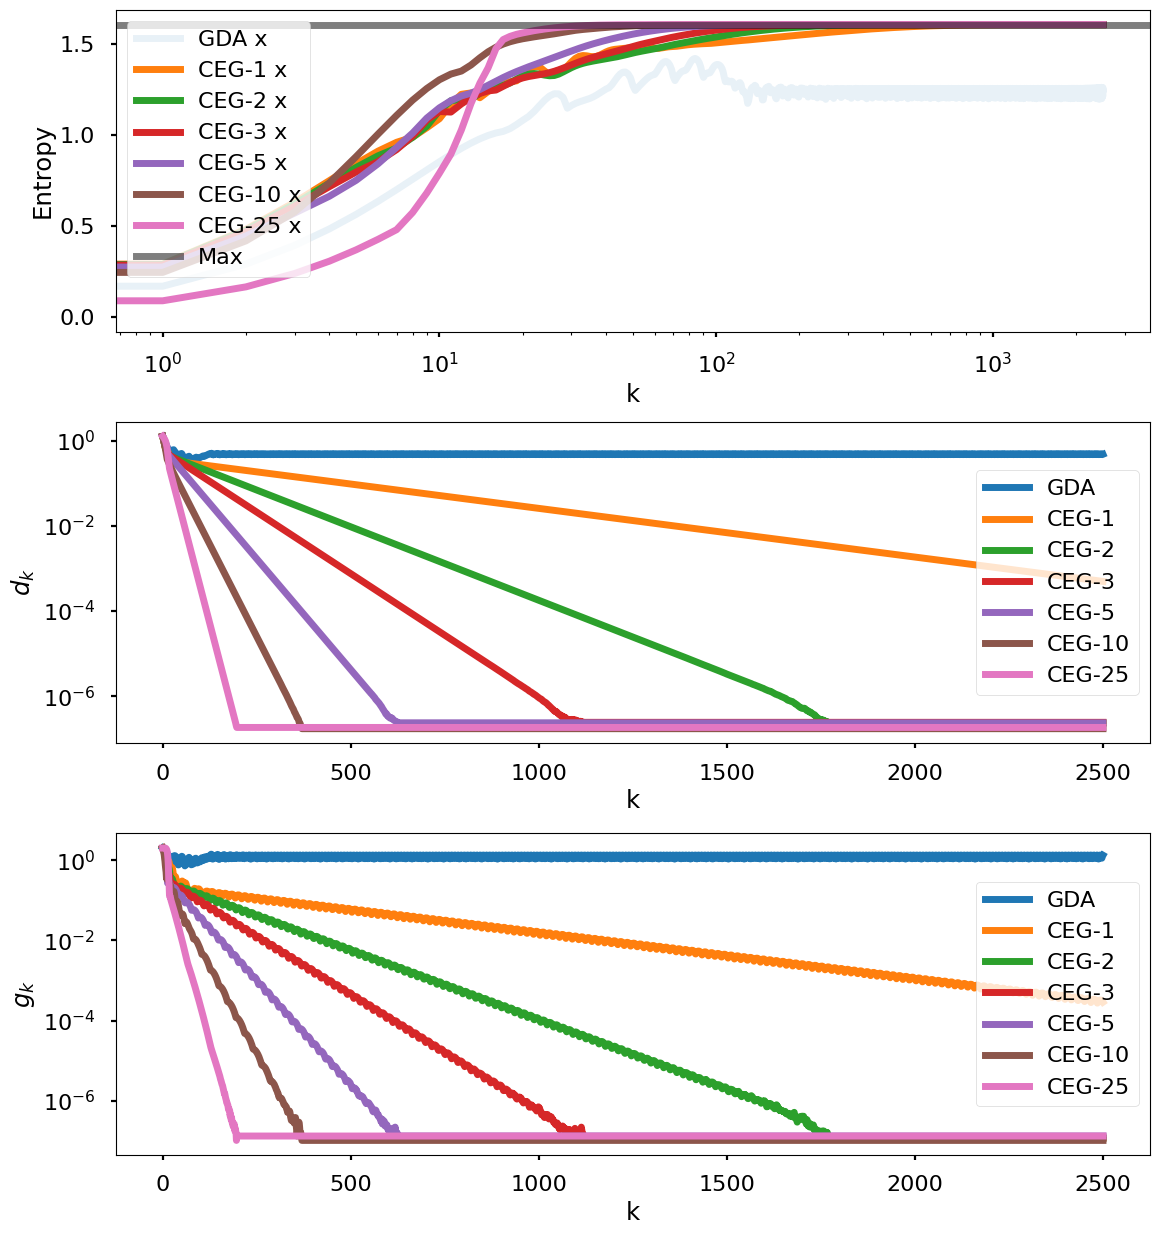

In [105]:
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(3, 1, figsize=(11.7, 1.5 * 8.3))
ax[0].plot(range(len(gda_x_sequence)), entropy(gda_x_sequence, axis=1), lw=5, alpha=0.1, label="GDA x")
ax[1].plot(range(len(gda_x_sequence)), distance_to_opt(gda_x_sequence, gda_y_sequence), lw=5, label="GDA")
ax[2].plot(range(len(gda_x_sequence)), duality_gap(gda_x_sequence, gda_y_sequence), lw=5, label="GDA")
for m, ceg_x_sequence, ceg_y_sequence in zip(m_values, ceg_x_sequences, ceg_y_sequences):
    ax[0].plot(range(len(ceg_x_sequence)), entropy(ceg_x_sequence, axis=1), lw=5, label=f"CEG-{m} x")
    ax[1].plot(range(len(ceg_x_sequence)), distance_to_opt(ceg_x_sequence, ceg_y_sequence), lw=5, label=f"CEG-{m}")
    ax[2].plot(range(len(ceg_x_sequence)), duality_gap(ceg_x_sequence, ceg_y_sequence), lw=5, label=f"CEG-{m}")
ax[0].axline((0, np.log(5)), slope=0, color='black', lw=5, alpha=0.5, label="Max")
ax[0].legend()
ax[0].set_xscale("log")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Entropy")
ax[1].legend()
ax[1].set_yscale("log")
ax[1].set_xlabel("k")
ax[1].set_ylabel("$d_k$")
ax[2].legend()
ax[2].set_yscale("log")
ax[2].set_xlabel("k")
ax[2].set_ylabel("$g_k$")
fig.tight_layout()
plt.show()
fig.tight_layout()
plt.show()

**(7)** (5 points) Discuss what you observe for the CEG runs. How do the value of $m$ and the step size influence the convergence and the computation cost? Is there a sweet spot?




- As m increases, the algorithm converges faster, but the computational cost also grows.

- 